In [1]:
import numpy as np
import matplotlib.pyplot as plt
from regions import Regions
import regions
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.modeling import models, fitting
from astropy.table import Table

from dust_extinction.averages import CT06_MWGC 

from smart_plotters.jwst_plots import JWSTCatalog, make_cat_use, make_brick_cat
from smart_plotters.cutout_plot import get_cutout_405, get_cutout_jwst_ice
import smart_plotters.co_ice as co_map
from smart_plotters import cmd_plot 

from mpl_plot_templates import adaptive_param_plot


        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]


In [3]:
D = 4*u.m
wave = 2.12*u.micron
resolution = (1.22*wave/D*u.rad).to(u.arcsec)
resolution

<Quantity 0.13337082 arcsec>

In [82]:
cat_brick = make_brick_cat()

Reading /orange/adamginsburg/jwst/brick/catalogs/basic_merged_indivexp_photometry_tables_merged_qualcuts_oksep2221.fits


In [83]:
fn_brick = '/orange/adamginsburg/jwst/brick/F405N/pipeline/jw02221-o001_t001_nircam_clear-f405n-merged_i2d.fits'
hdu_brick = fits.open(fn_brick)
ww_brick = WCS(hdu_brick['SCI'].header)
nanfield_brick = np.nan * hdu_brick['SCI'].data

In [84]:
reg_brick_north = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_north.reg')
reg_brick_south = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_south.reg')
reg_brick_head = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_head.reg')
reg_brick_sfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfluff.reg')
reg_brick_nfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nfluff.reg')
reg_brick_sfr = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr_tight.reg')
reg_brick_sfrwide = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr.reg')
reg_brick_punch = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_punch.reg')
reg_brick_sfore = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfore.reg')
reg_brick_nclear = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nclear.reg')
#reg_brick_topL = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_topL.reg')
reg_brick_topc = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_topc.reg')
#reg_brick_fil = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_fil.reg')
reg_brick_middle = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_middle.reg')

reg_brick_sfr_tightest = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr_tightest.reg')


reg_brick_A = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_A.reg')
reg_brick_B = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_B.reg')
reg_brick_C = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_C.reg')
reg_brick_D = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_D.reg')

reg_brick_claw1 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/claw1.reg')
reg_brick_claw2 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/claw2.reg')
reg_brick_claw3 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/claw3.reg')

In [85]:
cat_brick_north = JWSTCatalog(cat_brick.table_region_mask(reg_brick_north, ww_brick)) #  
cat_brick_south = JWSTCatalog(cat_brick.table_region_mask(reg_brick_south, ww_brick))
cat_brick_head = JWSTCatalog(cat_brick.table_region_mask(reg_brick_head, ww_brick))
cat_brick_sfluff = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfluff, ww_brick))
cat_brick_nfluff = JWSTCatalog(cat_brick.table_region_mask(reg_brick_nfluff, ww_brick))
cat_brick_sfr = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfr, ww_brick))
cat_brick_punch = JWSTCatalog(cat_brick.table_region_mask(reg_brick_punch, ww_brick))
cat_brick_sfore = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfore, ww_brick))
cat_brick_nclear = JWSTCatalog(cat_brick.table_region_mask(reg_brick_nclear, ww_brick))
#cat_brick_topL = JWSTCatalog(cat_brick.table_region_mask(reg_brick_topL, ww_brick))
cat_brick_topc = JWSTCatalog(cat_brick.table_region_mask(reg_brick_topc, ww_brick))
#cat_brick_fil = JWSTCatalog(cat_brick.table_region_mask(reg_brick_fil, ww_brick))
cat_brick_sfrwide = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfrwide, ww_brick))
cat_brick_middle = JWSTCatalog(cat_brick.table_region_mask(reg_brick_middle, ww_brick))
cat_brick_sfr_tightest = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfr_tightest, ww_brick))

cat_brick_A = JWSTCatalog(cat_brick.table_region_mask(reg_brick_A, ww_brick))
cat_brick_B = JWSTCatalog(cat_brick.table_region_mask(reg_brick_B, ww_brick))
cat_brick_C = JWSTCatalog(cat_brick.table_region_mask(reg_brick_C, ww_brick))
cat_brick_D = JWSTCatalog(cat_brick.table_region_mask(reg_brick_D, ww_brick))

cat_brick_claw1 = JWSTCatalog(cat_brick.table_region_mask(reg_brick_claw1, ww_brick))
cat_brick_claw2 = JWSTCatalog(cat_brick.table_region_mask(reg_brick_claw2, ww_brick))
cat_brick_claw3 = JWSTCatalog(cat_brick.table_region_mask(reg_brick_claw3, ww_brick))

/scratch/local/28012873/ipykernel_3467929/1569385495.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


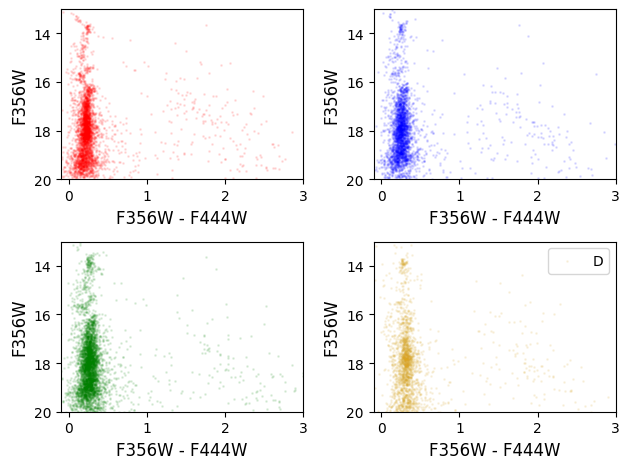

In [86]:
ax1 = plt.subplot(221)

cat_letters = [cat_brick_A, cat_brick_B, cat_brick_C, cat_brick_D]
labels_letters = ['A', 'B', 'C', 'D']
colors_letters = ['red', 'blue', 'green', 'goldenrod']

#cat_brick_A_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='red', s=5, label='A', marker='o', ax=ax1)

ax2 = plt.subplot(222)
#cat_brick_B_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='blue', s=5, label='B', marker='>', ax=ax2)

ax3 = plt.subplot(223)
#cat_brick_C_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='green', s=5, label='C', marker='s', ax=ax3)

ax4 = plt.subplot(224)
#cat_brick_D_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='goldenrod', s=5, label='D', marker='^', ax=ax4)

axes = [ax1, ax2, ax3, ax4]
for i in range(4):
    ax = axes[i]
    cat = cat_letters[i]
    label = labels_letters[i]
    color = colors_letters[i]
    
    cat.plot_CMD('f356w', 'f444w', 'f356w', color=color, s=1, alpha=0.1, label=label, ax=ax)
    ax.set_xlabel('F356W - F444W', fontsize=12)
    ax.set_ylabel('F356W', fontsize=12)
    ax.set_xlim(-0.1, 3)
    ax.set_ylim(20, 13)
    #plt.sca(ax)
    #plt.plot([0.8, 1.75], [-0.6, -1.7], color='k', linestyle='dashed')
    
    #ax.axvline(0.65, color='k', linestyle='--')
    plt.legend()

plt.tight_layout()

In [87]:
column_names = ['M/Mo(ini)', 'M/Mo(fin)', 'log(L/Lo)', 'logTe', 'F070W', 'F090W', 'F115W', 'F150W', 'F200W', 'F277W', 'F356W', 'F444W', 'F150W2', 'F322W2', 'F140M', 'F162M', 'F182M', 'F210M', 'F250M', 'F300M', 'F335M', 'F360M', 'F410M', 'F430M', 'F460M', 'F480M']

In [88]:
isochrone = Table.read('/orange/adamginsburg/jwst/cloudc/trilegal/abruzzo/FEHp006/10000z0172100y269P00O0D0E0.isc_jwst-nircam_PL', format='ascii', names=column_names)

In [89]:
isochrone

M/Mo(ini),M/Mo(fin),log(L/Lo),logTe,F070W,F090W,F115W,F150W,F200W,F277W,F356W,F444W,F150W2,F322W2,F140M,F162M,F182M,F210M,F250M,F300M,F335M,F360M,F410M,F430M,F460M,F480M
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0.1,0.1,-3.13618,3.42619,14.2327,11.9537,10.8008,10.1835,9.8445,9.7846,9.1743,9.0531,10.2276,9.4705,10.4615,9.8041,9.9659,9.6947,9.8271,9.7055,9.304,9.0828,8.9731,9.0312,9.1696,9.1437
0.102560935,0.102560935,-3.09514,3.43214,14.0373,11.8213,10.7051,10.0863,9.7474,9.6751,9.097,8.9733,10.1332,9.3797,10.3497,9.7218,9.8622,9.6062,9.7187,9.601,9.2223,9.0089,8.899,8.9515,9.0817,9.0566
0.10512187,0.10512187,-3.0551,3.43793,13.8394,11.6944,10.6135,9.9935,9.654,9.5693,9.0221,8.8963,10.0428,9.2915,10.2436,9.6433,9.7629,9.5205,9.6142,9.4995,9.1429,8.9374,8.8276,8.8749,8.9967,8.9721
0.1076828049,0.1076828049,-3.01602,3.44359,13.6431,11.5725,10.5253,9.9046,9.5639,9.4677,8.9494,8.8218,9.9557,9.2062,10.1425,9.5675,9.6677,9.4375,9.5136,9.4016,9.0657,8.8681,8.7586,8.8011,8.9147,8.8903
0.1102437399,0.1102437399,-2.97785,3.44912,13.4523,11.4544,10.4394,9.8183,9.4769,9.3708,8.8788,8.75,9.8712,9.1241,10.0455,9.4934,9.576,9.3566,9.4177,9.308,8.9909,8.8007,8.6917,8.7298,8.8359,8.8118
0.1128046749,0.1128046749,-2.94056,3.45453,13.2692,11.3396,10.3552,9.7341,9.3924,9.279,8.8101,8.6807,9.7888,9.0451,9.9519,9.4202,9.4875,9.2776,9.3265,9.219,8.9182,8.735,8.6268,8.6608,8.7605,8.7368
0.1153656099,0.1153656099,-2.9041,3.45981,13.0932,11.228,10.2726,9.6519,9.3104,9.1915,8.7433,8.6137,9.7083,8.9689,9.8616,9.348,9.402,9.2005,9.2394,9.134,8.8477,8.6708,8.5636,8.5941,8.6883,8.6649
0.1179265448,0.1179265448,-2.86843,3.46498,12.9237,11.1197,10.1918,9.5716,9.2307,9.1077,8.6782,8.5488,9.6296,8.8953,9.7741,9.2769,9.319,9.1252,9.1559,9.0525,8.7792,8.6081,8.5021,8.5296,8.6189,8.5958
0.1204874798,0.1204874798,-2.83555,3.46952,12.7734,11.0217,10.1169,9.4975,9.1571,9.0313,8.6173,8.4884,9.5569,8.8273,9.6942,9.2103,9.2427,9.0553,9.0798,8.9779,8.7155,8.5493,8.4443,8.4695,8.5549,8.5321


Text(0, 0.5, 'F356W')

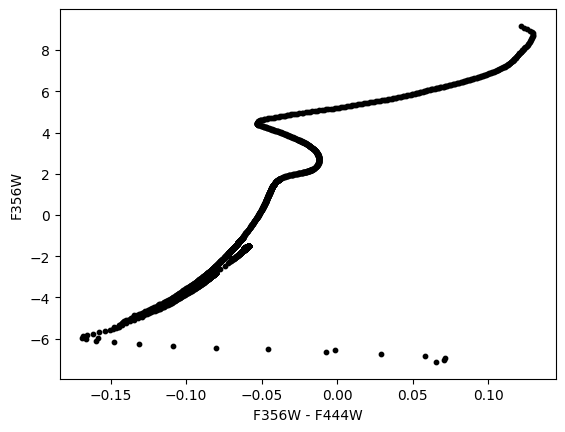

In [90]:
plt.scatter(isochrone['F356W'] - isochrone['F444W'], isochrone['F356W'], color='k', s=10, label='Isochrone')
plt.xlabel('F356W - F444W')
plt.ylabel('F356W')

In [91]:
distance = 8*u.kpc 
distance_modulus = 5 * np.log10(distance.to(u.pc).value) - 5

extinction = 20#*u.mag
ext = CT06_MWGC()

In [92]:
def extincted_band(tbl, band, wavelength, distance_modulus=distance_modulus, Av=extinction):
    return tbl[band] + distance_modulus + Av*ext(wavelength)

In [93]:
distance_modulus

np.float64(14.515449934959719)

In [95]:
isochrone['F356W'] + distance_modulus + extinction*ext(3.56*u.micron)

24.901896991139495
24.824596991139494
24.749696991139494
24.676996991139493
24.60639699113949
24.53769699113949
24.47089699113949
24.405796991139493
24.344896991139493
24.29649699113949
24.248996991139492


In [96]:
extinction*ext(3.56*u.micron)

1.2121470561797751

In [97]:
isochrone['F356W_ext'] = extincted_band(isochrone, 'F356W', 3.56*u.micron)
isochrone['F444W_ext'] = extincted_band(isochrone, 'F444W', 4.44*u.micron)

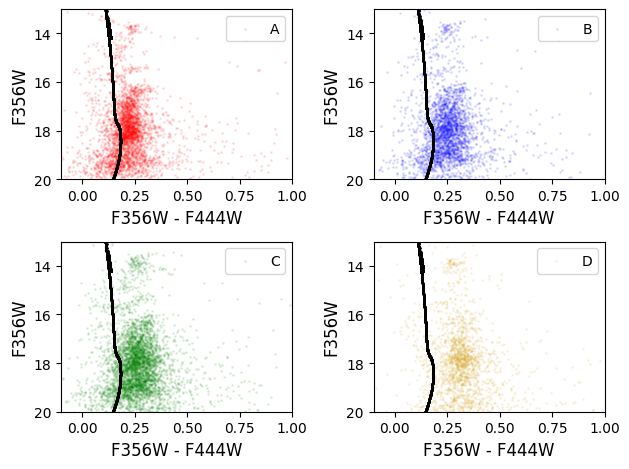

In [98]:
cat_letters = [cat_brick_A, cat_brick_B, cat_brick_C, cat_brick_D]
labels_letters = ['A', 'B', 'C', 'D']
colors_letters = ['red', 'blue', 'green', 'goldenrod']

ax1 = plt.subplot(221)

ax2 = plt.subplot(222)

ax3 = plt.subplot(223)

ax4 = plt.subplot(224)

axes = [ax1, ax2, ax3, ax4]
for i in range(4):
    ax = axes[i]
    cat = cat_letters[i]
    label = labels_letters[i]
    color = colors_letters[i]
    
    cat.plot_CMD('f356w', 'f444w', 'f356w', color=color, s=1, alpha=0.1, label=label, ax=ax)
    ax.scatter(isochrone['F356W_ext'] - isochrone['F444W_ext'], isochrone['F356W_ext'], color='k', s=1)
    ax.set_xlabel('F356W - F444W', fontsize=12)
    ax.set_ylabel('F356W', fontsize=12)
    ax.set_xlim(-0.1, 1)
    ax.set_ylim(20, 13)
    #plt.sca(ax)
    #plt.plot([0.8, 1.75], [-0.6, -1.7], color='k', linestyle='dashed')
    
    #ax.axvline(0.65, color='k', linestyle='--')
    ax.legend()

plt.tight_layout()